In [1]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt

In [2]:
def detect_and_crop_local(cv2_img, model_path='blaze_face_short_range.tflite'):

    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceDetectorOptions(base_options=base_options)

    with vision.FaceDetector.create_from_options(options) as detector:
        # converting bgr to rgb - the format supported by mediapipe
        rgb_img = cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB)

        #creating a mediapipe image
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_img)

        #detection
        detection_result = detector.detect(mp_image)

        # if not detection_result.detections:
        #     print("No face detected.")
        #     return None

        # Bounding Box to enclsoe the face
        bbox = detection_result.detections[0].bounding_box
        x, y, w, h = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height

        #crop
        ih, iw, _ = cv2_img.shape
        x_min, y_min = max(0, x), max(0, y)
        x_max, y_max = min(iw, x + w), min(ih, y + h)

        face_crop = cv2_img[y_min:y_max, x_min:x_max]

        # resize to 112x112 - the size supported by arcface for its input
        return cv2.resize(face_crop, (112, 112), interpolation=cv2.INTER_AREA)

the code beneath is only for testing. this wont be there in the final file

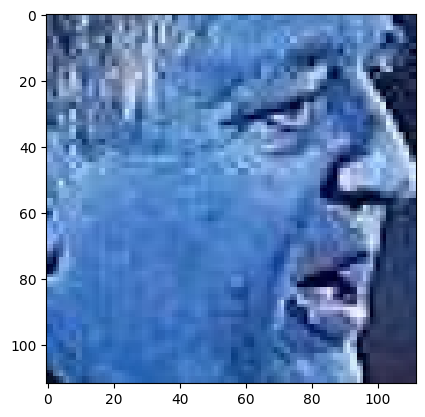

In [3]:
img = cv2.imread('person/img_3.jpg')
face = detect_and_crop_local(img)
plt.imshow(face)